In [ ]:
# !pip install yfinance
# !pip install bs4
# !pip install nbformat
# !pip install matplotlib

  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt 



In [3]:
import warnings
#ignore all warnings
warnings.filterwarnings("ignore",category=FutureWarning)

***In this section, we define the function make_graph. You don't have to know how the function works, you should only care about the inputs. It takes a dataframe with stock data (dataframe must contain Date and Close columns), a dataframe with revenue data (dataframe must contain Date and Revenue columns), and the name of the stock.***

In [4]:
def make_graph(stock_data,revenue_data,stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig,axes = plt.Subplot(2,1,figsize=(12,4),sharex=True)

    #stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date),stock_data_specific.Close_astype("float"))


    #revenue price

# Question 1: Use yfinance to Extract Stock Data

 **Using the Ticker function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is TSLA.**

In [5]:
tesla = yf.Ticker('TSLA')



**Using the ticker object and the function history extract stock information and save it in a dataframe named tesla_data. Set the period parameter to "max" so we get information for the maximum amount of time.**

In [6]:
tesla_data = tesla.history(period = "max")

**Reset the index using the reset_index(inplace=True) function on the tesla_data DataFrame and display the first five rows of the tesla_data dataframe using the head function. Take a screenshot of the results and code from the beginning of Question 1 to the results below**

In [8]:
tesla_data.reset_index(inplace=True)

# Question 2: Use Webscraping to Extract Tesla Revenue Data

In [20]:
from bs4 import BeautifulSoup
import requests
import pandas as pd 

webpage = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm "
r = requests.get(webpage)
soup = BeautifulSoup(r.content,"html.parser")
tesla_revenue = pd.DataFrame(columns=["Date","Revenue"])
tables = soup.find_all("table")
for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.tbody.find_all("tr"):
            col = row.find_all("td")
            if len(col) == 2:
                date = col[0].text.strip()
                revenue = col[1].text.strip()
                tesla_revenue.loc[len(tesla_revenue)] = [date,revenue]
tesla_revenue.head()

c:\Users\divya\anaconda3\Lib\html\parser.py:189: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  k = self.parse_starttag(i)


,Date,Revenue


**Using BeautifulSoup or the read_html function extract the table with Tesla Revenue and store it into a dataframe named tesla_revenue. The dataframe should have columns Date and Revenue.**

In [12]:
tesla_revenue = pd.DataFrame(columns=["Date","Revenue"])
tables = soup.find_all("tables")
for table in tables:
    if "Tesla Quarterly Revenue" in str(table):
        for row in table.tbody.find_all("tr"):
            col = row.find_all("td")
            if len(col) == 2:
                date = col[0].text.strip()
                revenue = col[0].text.strip()
                tesla_revenue.loc[len(tesla_revenue)] = ["date","revenue"]
tesla_revenue.head()


,Date,Revenue


In [13]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

In [14]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [ ]:
tesla_revenue.tail(10)

,Date,Revenue


 # Question 3: Use yfinance to Extract Stock Data

In [17]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

tesla = yf.Ticker('GME')
gme_data = tesla.history(period = "max")
gme_data.reset_index(inplace = True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662209,1.603296,1.662209,6892800,0.0,0.0


In [22]:
# !pip install yfinance
# !pip install bs4
# !pip install nbformat
#!pip install matplotlib

import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## final projecct 

**import all librraries**

In [23]:
import yfinance as yf
import pandas as pd
from bs4 import BeautifulSoup
import requests
import matplotlib.pyplot as plt

In [32]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

**Tesla stock Data**

In [33]:
tesla = yf.Ticker('TSLA')
tesla_data = tesla.history(period = "max")
tesla_data.reset_index(inplace=True)
tesla_data.head(100)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0
...,...,...,...,...,...,...,...,...
95,2010-11-11 00:00:00-05:00,1.906667,1.940000,1.822000,1.869333,29179500,0.0,0.0
96,2010-11-12 00:00:00-05:00,1.883333,2.033333,1.871333,1.989333,40936500,0.0,0.0
97,2010-11-15 00:00:00-05:00,2.014667,2.196000,2.014667,2.053333,39343500,0.0,0.0
98,2010-11-16 00:00:00-05:00,2.066667,2.093333,1.894667,1.978000,20214000,0.0,0.0


**BeautifulSoup**

In [34]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm "
r = requests.get(url)
soup = BeautifulSoup(r.content,"html.parser")
tesla_revenue = pd.DataFrame(columns = ["Date","Revenue"])

c:\Users\divya\anaconda3\Lib\html\parser.py:189: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  k = self.parse_starttag(i)


In [ ]:
# ==========================================
# Step 1: Import Libraries
# ==========================================
import requests
from bs4 import BeautifulSoup
import pandas as pd

# ==========================================
# Step 2: Website URL
# ==========================================
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

# ==========================================
# Step 3: Download HTML
# ==========================================
response = requests.get(url)

# ==========================================
# Step 4: Create BeautifulSoup Object
# ==========================================
soup = BeautifulSoup(response.content, "html.parser")

# ==========================================
# Step 5: Create Empty DataFrame
# ==========================================
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# ==========================================
# Step 6: Find All Tables
# ==========================================
tables = soup.find_all("table")

# ==========================================
# Step 7: Find Tesla Quarterly Revenue Table
# ==========================================
for table in tables:

    if "Tesla Quarterly Revenue" in str(table):

        # ==========================================
        # Step 8: Loop Through Every Row
        # ==========================================
        for row in table.tbody.find_all("tr"):

            cols = row.find_all("td")

            # Check if row has exactly 2 columns
            if len(cols) == 2:

                date = cols[0].text.strip()
                revenue = cols[1].text.strip()

                # Add row into DataFrame
                tesla_revenue.loc[len(tesla_revenue)] = [date, revenue]

# ==========================================
# Step 9: Clean Revenue Column
# ==========================================
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",", "", regex=False)

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace("$", "", regex=False)

# Remove empty rows
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

# Convert Revenue into float
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].astype(float)

# Convert Date into datetime
tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])

# ==========================================
# Step 10: Display First Five Rows
# ==========================================
print(tesla_revenue.head())


print(tesla_revenue.tail())


tesla_revenue.to_csv("tesla_revenue.csv", index=False)

print("CSV file saved successfully!")

        Date  Revenue
0 2022-09-30  21454.0
1 2022-06-30  16934.0
2 2022-03-31  18756.0
3 2021-12-31  17719.0
4 2021-09-30  13757.0
         Date  Revenue
48 2010-09-30     31.0
49 2010-06-30     28.0
50 2010-03-31     21.0
52 2009-09-30     46.0
53 2009-06-30     27.0
CSV file saved successfully!


# plot graph

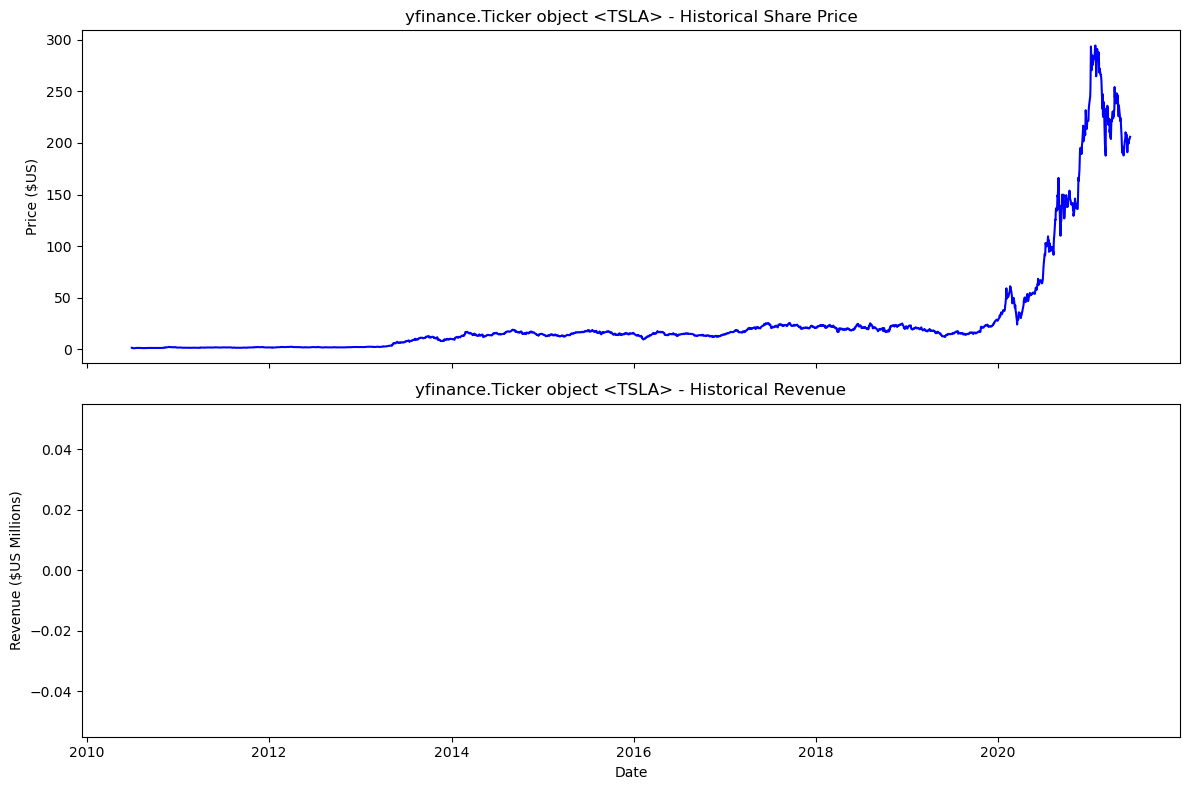

In [42]:
make_graph(tesla_data,tesla_revenue,tesla)